# Online Retail II — Retention and Cohort Analysis

This notebook measures customer retention using monthly acquisition cohorts, repeat-purchase behaviour, and customer lifecycle metrics.

Only eligible merchandise sales with valid customer IDs are included.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [2]:
# Locate the project folder
current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

data_path = (
    project_root
    / "data"
    / "processed"
    / "retail_transactions_clean.csv.gz"
)

print("Project root:", project_root)
print("Dataset path:", data_path)
print("Dataset exists:", data_path.exists())

Project root: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics
Dataset path: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\data\processed\retail_transactions_clean.csv.gz
Dataset exists: True


In [3]:
retail = pd.read_csv(
    data_path,
    compression="gzip",
    parse_dates=["invoice_date"],
    low_memory=False
)

print("Dataset shape:", retail.shape)
print(
    "Date range:",
    retail["invoice_date"].min(),
    "to",
    retail["invoice_date"].max()
)

retail.head()

Dataset shape: (1033036, 14)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,source_year,transaction_type,line_category,line_value,data_quality_flag,analysis_eligible
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,Year 2009-2010,Sale,Merchandise,83.40,Standard,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010,Sale,Merchandise,81.00,Standard,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010,Sale,Merchandise,81.00,Standard,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,Year 2009-2010,Sale,Merchandise,100.80,Standard,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,Year 2009-2010,Sale,Merchandise,30.00,Standard,True


In [4]:
customer_sales = retail.loc[
    retail["analysis_eligible"].eq(True)
    & retail["line_category"].eq("Merchandise")
    & retail["transaction_type"].eq("Sale")
    & retail["customer_id"].notna()
    & retail["quantity"].gt(0)
    & retail["unit_price"].gt(0)
].copy()

customer_sales["customer_id"] = customer_sales["customer_id"].astype("Int64")

customer_sales["invoice_month"] = (
    customer_sales["invoice_date"].dt.to_period("M")
)

customer_sales["cohort_month"] = (
    customer_sales.groupby("customer_id")["invoice_month"]
    .transform("min")
)

print("Eligible customer sales rows:", len(customer_sales))
print("Unique sales invoices:", customer_sales["invoice_no"].nunique())
print("Customers analyzed:", customer_sales["customer_id"].nunique())
print("First purchase month:", customer_sales["invoice_month"].min())
print("Latest purchase month:", customer_sales["invoice_month"].max())

customer_sales[
    [
        "customer_id",
        "invoice_no",
        "invoice_date",
        "invoice_month",
        "cohort_month",
        "line_value"
    ]
].head()

Eligible customer sales rows: 776595
Unique sales invoices: 36593
Customers analyzed: 5852
First purchase month: 2009-12
Latest purchase month: 2011-12


,customer_id,invoice_no,invoice_date,invoice_month,cohort_month,line_value
0,13085,489434,2009-12-01 07:45:00,2009-12,2009-12,83.40
1,13085,489434,2009-12-01 07:45:00,2009-12,2009-12,81.00
2,13085,489434,2009-12-01 07:45:00,2009-12,2009-12,81.00
3,13085,489434,2009-12-01 07:45:00,2009-12,2009-12,100.80
4,13085,489434,2009-12-01 07:45:00,2009-12,2009-12,30.00


In [5]:
customer_sales["cohort_index"] = (
    (
        customer_sales["invoice_month"].dt.year
        - customer_sales["cohort_month"].dt.year
    )
    * 12
    + (
        customer_sales["invoice_month"].dt.month
        - customer_sales["cohort_month"].dt.month
    )
    + 1
)

cohort_activity = (
    customer_sales.groupby(
        ["cohort_month", "cohort_index"],
        observed=True
    )["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)

cohort_counts = cohort_activity.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="active_customers"
)

cohort_sizes = cohort_counts[1]

retention_matrix = (
    cohort_counts.divide(cohort_sizes, axis=0) * 100
)

print("Number of acquisition cohorts:", len(cohort_counts))
print("Total customers in cohort sizes:", int(cohort_sizes.sum()))

retention_matrix.round(2)

Number of acquisition cohorts: 25
Total customers in cohort sizes: 5852


cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,35.02,33.33,42.48,37.85,35.96,37.64,34.38,33.75,36.17,42.17,49.63,37.64,28.18,24.40,30.28,26.29,30.28,28.39,25.87,25.45,31.34,30.39,40.59,19.66
2010-01,100.00,21.47,32.07,31.52,27.17,30.98,26.90,23.37,28.53,32.61,30.98,17.93,22.83,17.93,19.57,15.22,24.46,20.38,19.29,20.11,25.27,19.84,25.27,5.71,NaN
2010-02,100.00,23.47,22.67,29.33,24.53,19.73,19.20,28.80,25.60,27.73,11.47,12.53,15.20,17.60,12.27,20.00,16.00,16.27,14.40,22.93,22.93,16.53,5.87,NaN,NaN
2010-03,100.00,19.05,23.13,24.26,23.13,20.41,24.72,30.61,27.66,10.88,11.56,14.51,19.95,16.33,19.95,17.01,17.46,15.65,17.69,20.41,21.32,7.71,NaN,NaN,NaN
2010-04,100.00,19.05,19.05,15.99,18.37,22.11,27.55,26.53,10.54,10.88,7.48,13.95,14.29,15.65,15.65,15.65,13.95,14.97,18.03,22.79,5.78,NaN,NaN,NaN,NaN
2010-05,100.00,15.69,16.86,17.65,17.65,25.49,21.18,12.55,5.88,8.24,11.37,13.33,15.29,15.29,9.80,12.55,13.73,16.47,15.29,4.71,NaN,NaN,NaN,NaN,NaN
2010-06,100.00,17.60,18.73,20.60,23.22,28.46,12.73,8.99,8.24,11.24,10.49,13.86,14.98,12.36,11.24,12.36,13.11,20.22,4.87,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.00,15.68,18.38,29.73,29.19,14.05,11.35,14.59,14.59,11.35,13.51,14.59,12.97,13.51,19.46,17.30,23.78,8.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.00,19.63,28.83,32.52,16.56,11.66,9.82,12.88,13.50,12.88,12.88,11.66,14.72,17.18,17.18,19.63,7.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


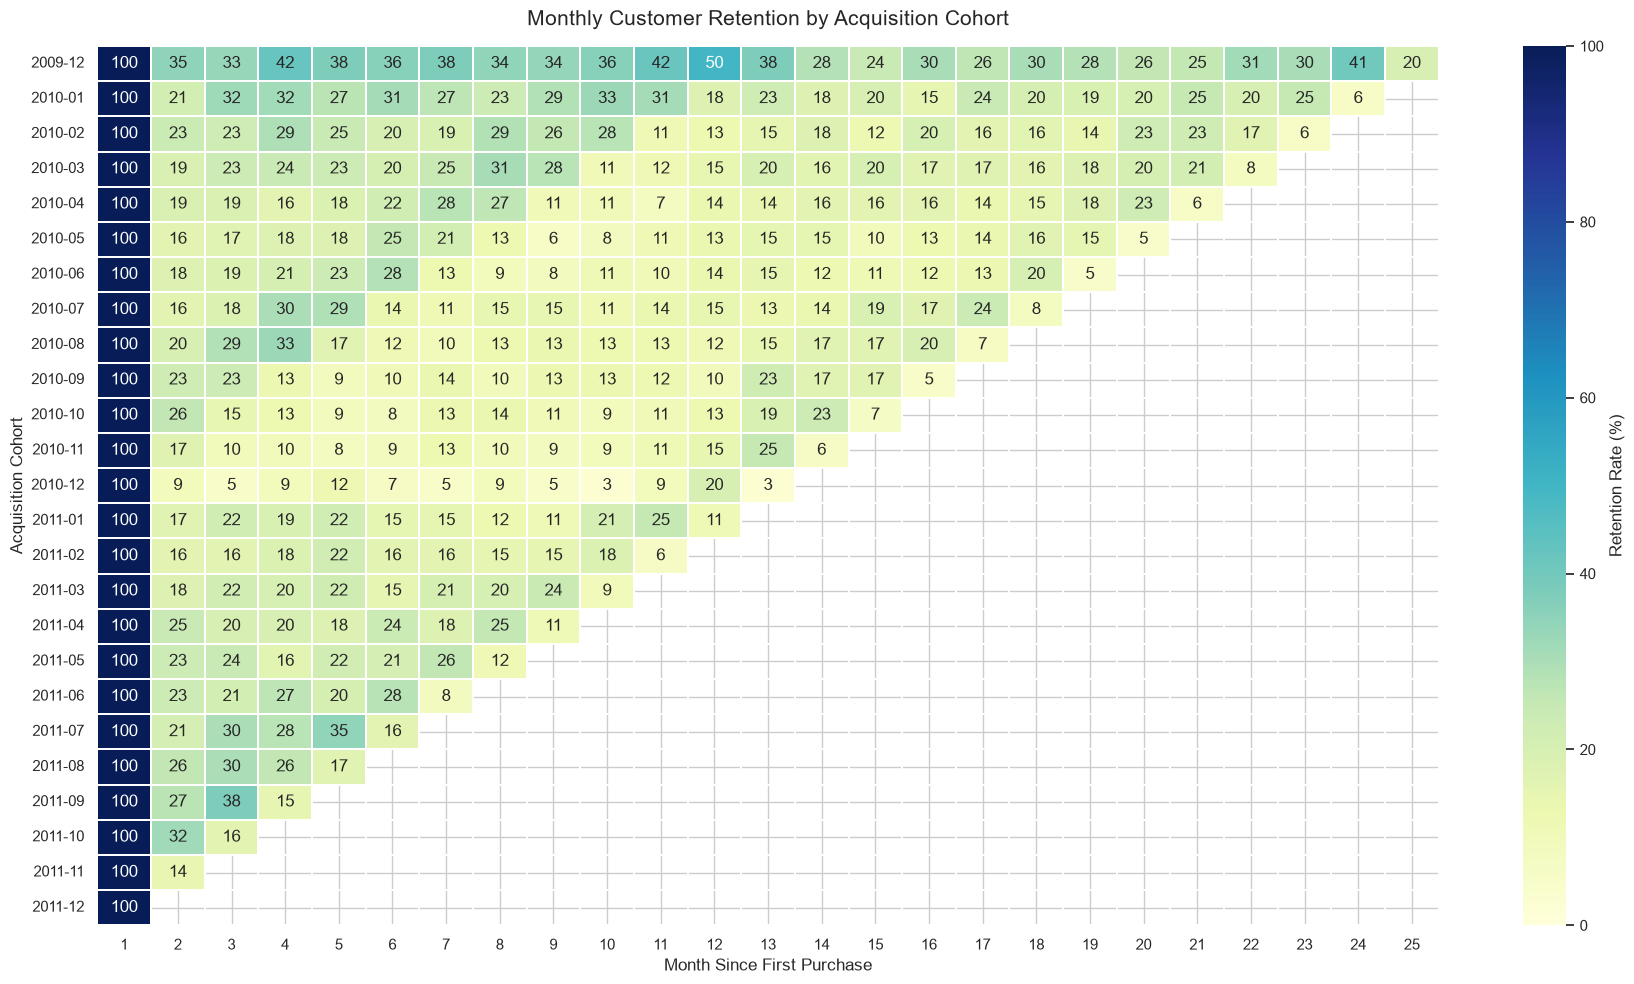

In [6]:
plt.figure(figsize=(18, 10))

sns.heatmap(
    retention_matrix,
    mask=retention_matrix.isna(),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.3,
    cbar_kws={"label": "Retention Rate (%)"}
)

plt.title(
    "Monthly Customer Retention by Acquisition Cohort",
    fontsize=15,
    pad=15
)
plt.xlabel("Month Since First Purchase")
plt.ylabel("Acquisition Cohort")
plt.tight_layout()
plt.show()

In [7]:
retention_kpi_records = []

for month_number in [2, 3, 6, 12]:
    eligible_cohorts = cohort_counts[month_number].notna()

    eligible_customers = cohort_sizes.loc[eligible_cohorts].sum()
    retained_customers = (
        cohort_counts.loc[eligible_cohorts, month_number].sum()
    )

    retention_rate = (
        retained_customers / eligible_customers * 100
    )

    retention_kpi_records.append(
        {
            "retention_period": f"Month {month_number}",
            "eligible_cohorts": int(eligible_cohorts.sum()),
            "eligible_customers": int(eligible_customers),
            "retained_customers": int(retained_customers),
            "weighted_retention_pct": retention_rate
        }
    )

retention_kpis = pd.DataFrame(retention_kpi_records)

retention_kpis.style.format(
    {"weighted_retention_pct": "{:.2f}%"}
)

,retention_period,eligible_cohorts,eligible_customers,retained_customers,weighted_retention_pct
0,Month 2,24,5824,1342,23.04%
1,Month 3,23,5633,1312,23.29%
2,Month 6,20,5117,1113,21.75%
3,Month 12,14,4387,950,21.65%


In [8]:
customer_lifecycle = (
    customer_sales.groupby("customer_id")
    .agg(
        first_purchase_date=("invoice_date", "min"),
        last_purchase_date=("invoice_date", "max"),
        sales_invoices=("invoice_no", "nunique"),
        active_purchase_months=("invoice_month", "nunique"),
        gross_sales=("line_value", "sum"),
        units_purchased=("quantity", "sum")
    )
    .reset_index()
)

customer_lifecycle["customer_lifetime_days"] = (
    customer_lifecycle["last_purchase_date"]
    - customer_lifecycle["first_purchase_date"]
).dt.days

customer_lifecycle["average_order_value"] = (
    customer_lifecycle["gross_sales"]
    / customer_lifecycle["sales_invoices"]
)

customer_lifecycle["customer_status"] = np.where(
    customer_lifecycle["sales_invoices"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

total_customers = len(customer_lifecycle)

repeat_customers = (
    customer_lifecycle["customer_status"]
    .eq("Repeat Customer")
    .sum()
)

one_time_customers = (
    customer_lifecycle["customer_status"]
    .eq("One-Time Customer")
    .sum()
)

repeat_purchase_rate = repeat_customers / total_customers * 100

repeat_purchase_summary = pd.DataFrame(
    {
        "Metric": [
            "Total customers",
            "Repeat customers",
            "One-time customers",
            "Repeat purchase rate",
            "Median sales invoices",
            "Median customer lifetime days"
        ],
        "Result": [
            f"{total_customers:,}",
            f"{repeat_customers:,}",
            f"{one_time_customers:,}",
            f"{repeat_purchase_rate:.2f}%",
            f"{customer_lifecycle['sales_invoices'].median():,.0f}",
            f"{customer_lifecycle['customer_lifetime_days'].median():,.0f}"
        ]
    }
)

repeat_purchase_summary

,Metric,Result
0,Total customers,"5,852"
1,Repeat customers,"4,234"
2,One-time customers,"1,618"
3,Repeat purchase rate,72.35%
4,Median sales invoices,3
5,Median customer lifetime days,222


In [9]:
customer_status_summary = (
    customer_lifecycle.groupby("customer_status")
    .agg(
        customer_count=("customer_id", "nunique"),
        sales_invoices=("sales_invoices", "sum"),
        gross_sales=("gross_sales", "sum"),
        units_purchased=("units_purchased", "sum"),
        average_customer_sales=("gross_sales", "mean"),
        average_sales_invoices=("sales_invoices", "mean")
    )
    .reindex(["Repeat Customer", "One-Time Customer"])
    .reset_index()
)

customer_status_summary["customer_share_pct"] = (
    customer_status_summary["customer_count"]
    / customer_status_summary["customer_count"].sum()
    * 100
)

customer_status_summary["gross_sales_share_pct"] = (
    customer_status_summary["gross_sales"]
    / customer_status_summary["gross_sales"].sum()
    * 100
)

customer_status_summary.style.format(
    {
        "gross_sales": "£{:,.2f}",
        "average_customer_sales": "£{:,.2f}",
        "average_sales_invoices": "{:.2f}",
        "customer_share_pct": "{:.2f}%",
        "gross_sales_share_pct": "{:.2f}%"
    }
)

,customer_status,customer_count,sales_invoices,gross_sales,units_purchased,average_customer_sales,average_sales_invoices,customer_share_pct,gross_sales_share_pct
0,Repeat Customer,4234,34975,"£16,473,612.77",10070772,"£3,890.79",8.26,72.35%,96.74%
1,One-Time Customer,1618,1618,"£555,999.97",427923,£343.63,1.00,27.65%,3.26%


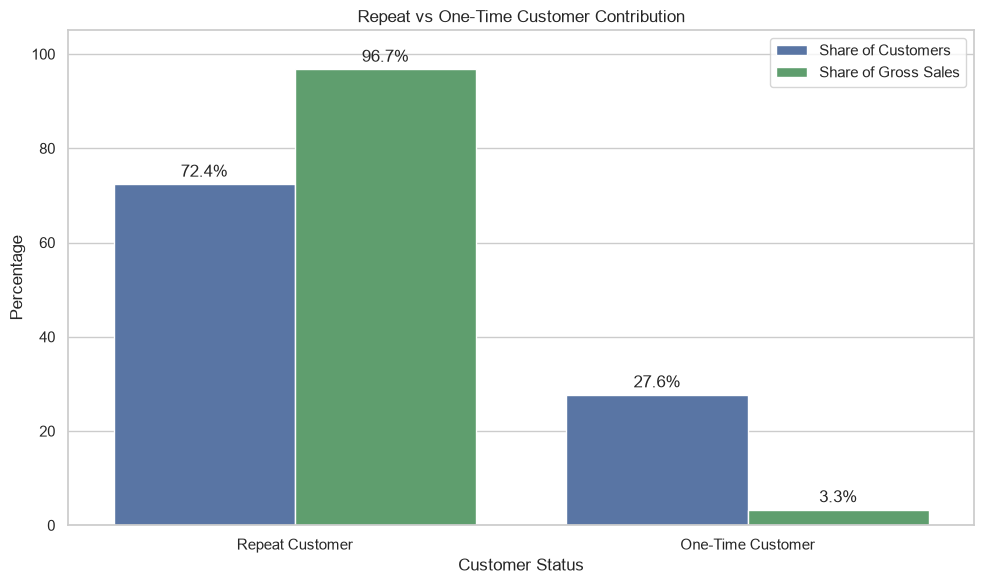

In [10]:
status_share_plot = customer_status_summary.melt(
    id_vars="customer_status",
    value_vars=[
        "customer_share_pct",
        "gross_sales_share_pct"
    ],
    var_name="measure",
    value_name="percentage"
)

status_share_plot["measure"] = status_share_plot["measure"].map(
    {
        "customer_share_pct": "Share of Customers",
        "gross_sales_share_pct": "Share of Gross Sales"
    }
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=status_share_plot,
    x="customer_status",
    y="percentage",
    hue="measure",
    palette=["#4C72B0", "#55A868"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Repeat vs One-Time Customer Contribution")
plt.xlabel("Customer Status")
plt.ylabel("Percentage")
plt.ylim(0, 105)
plt.legend(title="")
plt.tight_layout()
plt.show()

In [11]:
monthly_customer_activity = (
    customer_sales[
        ["customer_id", "invoice_month", "cohort_month"]
    ]
    .drop_duplicates()
)

monthly_customer_activity["customer_type"] = np.where(
    monthly_customer_activity["invoice_month"]
    .eq(monthly_customer_activity["cohort_month"]),
    "New Customer",
    "Returning Customer"
)

monthly_customer_summary = (
    monthly_customer_activity.groupby(
        ["invoice_month", "customer_type"]
    )["customer_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        columns=["New Customer", "Returning Customer"],
        fill_value=0
    )
    .reset_index()
)

monthly_customer_summary["active_customers"] = (
    monthly_customer_summary["New Customer"]
    + monthly_customer_summary["Returning Customer"]
)

monthly_customer_summary["returning_customer_share_pct"] = (
    monthly_customer_summary["Returning Customer"]
    / monthly_customer_summary["active_customers"]
    * 100
)

monthly_customer_summary.style.format(
    {"returning_customer_share_pct": "{:.2f}%"}
)

customer_type,invoice_month,New Customer,Returning Customer,active_customers,returning_customer_share_pct
0,2009-12,951,0,951,0.00%
1,2010-01,368,333,701,47.50%
2,2010-02,375,396,771,51.36%
3,2010-03,441,610,1051,58.04%
4,2010-04,294,645,939,68.69%
5,2010-05,255,710,965,73.58%
6,2010-06,267,767,1034,74.18%
7,2010-07,185,739,924,79.98%
8,2010-08,163,747,910,82.09%
9,2010-09,239,897,1136,78.96%


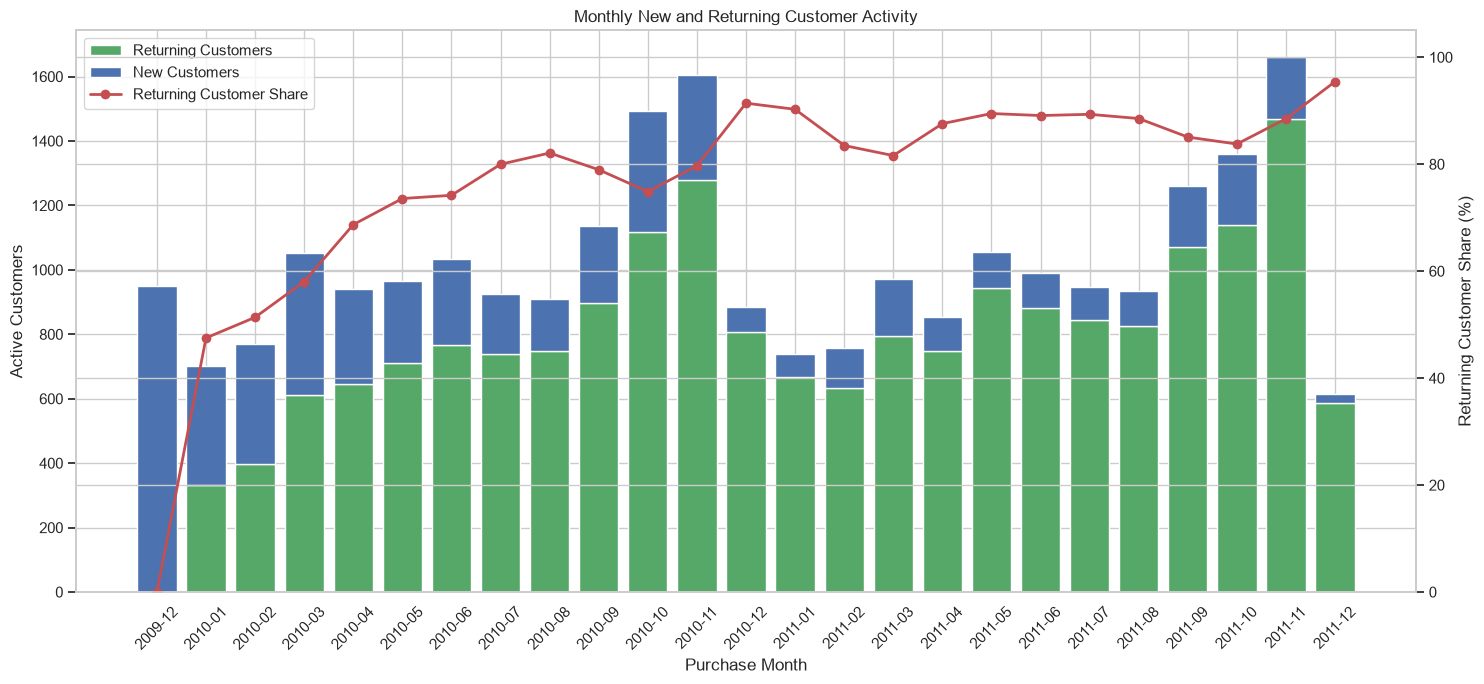

In [12]:
monthly_plot = monthly_customer_summary.copy()
monthly_plot["invoice_month_label"] = (
    monthly_plot["invoice_month"].astype(str)
)

fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.bar(
    monthly_plot["invoice_month_label"],
    monthly_plot["Returning Customer"],
    label="Returning Customers",
    color="#55A868"
)

ax1.bar(
    monthly_plot["invoice_month_label"],
    monthly_plot["New Customer"],
    bottom=monthly_plot["Returning Customer"],
    label="New Customers",
    color="#4C72B0"
)

ax1.set_title("Monthly New and Returning Customer Activity")
ax1.set_xlabel("Purchase Month")
ax1.set_ylabel("Active Customers")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    monthly_plot["invoice_month_label"],
    monthly_plot["returning_customer_share_pct"],
    color="#C44E52",
    marker="o",
    linewidth=2,
    label="Returning Customer Share"
)

ax2.set_ylabel("Returning Customer Share (%)")
ax2.set_ylim(0, 105)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [13]:
customer_orders = (
    customer_sales.groupby(
        ["customer_id", "invoice_no"],
        as_index=False
    )
    .agg(
        order_date=("invoice_date", "min"),
        order_value=("line_value", "sum")
    )
    .sort_values(
        ["customer_id", "order_date", "invoice_no"]
    )
)

customer_orders["purchase_number"] = (
    customer_orders.groupby("customer_id")
    .cumcount()
    .add(1)
)

first_orders = (
    customer_orders.loc[
        customer_orders["purchase_number"].eq(1),
        ["customer_id", "order_date"]
    ]
    .rename(columns={"order_date": "first_order_date"})
)

second_orders = (
    customer_orders.loc[
        customer_orders["purchase_number"].eq(2),
        ["customer_id", "order_date"]
    ]
    .rename(columns={"order_date": "second_order_date"})
)

second_purchase_analysis = first_orders.merge(
    second_orders,
    on="customer_id",
    how="inner"
)

second_purchase_analysis["days_to_second_purchase"] = (
    second_purchase_analysis["second_order_date"]
    - second_purchase_analysis["first_order_date"]
).dt.days

median_days = (
    second_purchase_analysis["days_to_second_purchase"].median()
)

average_days = (
    second_purchase_analysis["days_to_second_purchase"].mean()
)

within_30_days = (
    second_purchase_analysis["days_to_second_purchase"]
    .le(30)
    .mean()
    * 100
)

within_60_days = (
    second_purchase_analysis["days_to_second_purchase"]
    .le(60)
    .mean()
    * 100
)

within_90_days = (
    second_purchase_analysis["days_to_second_purchase"]
    .le(90)
    .mean()
    * 100
)

second_purchase_summary = pd.DataFrame(
    {
        "Metric": [
            "Customers reaching a second purchase",
            "Median days to second purchase",
            "Average days to second purchase",
            "Second purchase within 30 days",
            "Second purchase within 60 days",
            "Second purchase within 90 days"
        ],
        "Result": [
            f"{len(second_purchase_analysis):,}",
            f"{median_days:,.0f}",
            f"{average_days:,.2f}",
            f"{within_30_days:.2f}%",
            f"{within_60_days:.2f}%",
            f"{within_90_days:.2f}%"
        ]
    }
)

second_purchase_summary

,Metric,Result
0,Customers reaching a second purchase,"4,234"
1,Median days to second purchase,56
2,Average days to second purchase,98.54
3,Second purchase within 30 days,31.72%
4,Second purchase within 60 days,51.94%
5,Second purchase within 90 days,63.84%


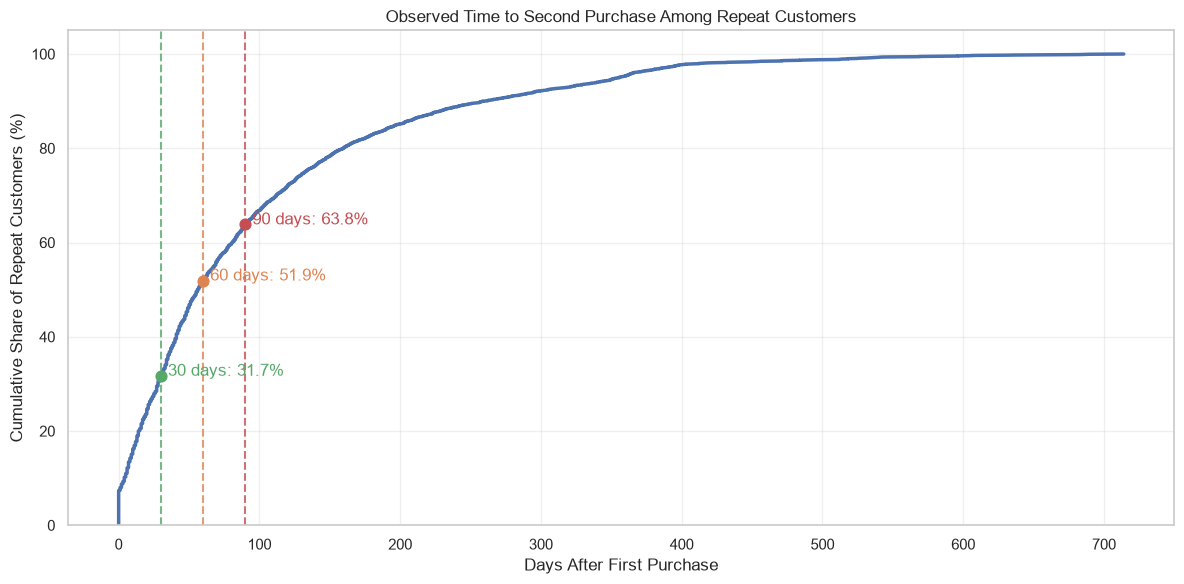

In [14]:
sorted_second_purchase_days = np.sort(
    second_purchase_analysis["days_to_second_purchase"]
)

cumulative_customer_pct = (
    np.arange(1, len(sorted_second_purchase_days) + 1)
    / len(sorted_second_purchase_days)
    * 100
)

plt.figure(figsize=(12, 6))

plt.plot(
    sorted_second_purchase_days,
    cumulative_customer_pct,
    color="#4C72B0",
    linewidth=2.5
)

for day, color in zip(
    [30, 60, 90],
    ["#55A868", "#DD8452", "#C44E52"]
):
    rate = (
        second_purchase_analysis["days_to_second_purchase"]
        .le(day)
        .mean()
        * 100
    )

    plt.axvline(
        day,
        color=color,
        linestyle="--",
        alpha=0.8
    )

    plt.scatter(day, rate, color=color, s=60, zorder=3)

    plt.text(
        day + 5,
        rate,
        f"{day} days: {rate:.1f}%",
        color=color
    )

plt.title("Observed Time to Second Purchase Among Repeat Customers")
plt.xlabel("Days After First Purchase")
plt.ylabel("Cumulative Share of Repeat Customers (%)")
plt.ylim(0, 105)
plt.grid(axis="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
latest_source_month = customer_sales["invoice_month"].max()
latest_source_date = customer_sales["invoice_date"].max()

latest_month_end = (
    latest_source_month.to_timestamp(how="end").normalize()
)

latest_month_is_partial = (
    latest_source_date.normalize() < latest_month_end
)

if latest_month_is_partial:
    cohort_sales = customer_sales.loc[
        customer_sales["invoice_month"] < latest_source_month
    ].copy()
else:
    cohort_sales = customer_sales.copy()

cohort_sales["cohort_index"] = (
    (
        cohort_sales["invoice_month"].dt.year
        - cohort_sales["cohort_month"].dt.year
    )
    * 12
    + (
        cohort_sales["invoice_month"].dt.month
        - cohort_sales["cohort_month"].dt.month
    )
    + 1
)

cohort_activity = (
    cohort_sales.groupby(
        ["cohort_month", "cohort_index"],
        observed=True
    )["customer_id"]
    .nunique()
    .reset_index(name="active_customers")
)

cohort_counts = cohort_activity.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="active_customers"
)

cohort_sizes = cohort_counts[1]

retention_matrix = (
    cohort_counts.divide(cohort_sizes, axis=0) * 100
)

print("Latest source month:", latest_source_month)
print("Latest source date:", latest_source_date)
print("Latest month is partial:", latest_month_is_partial)
print("Number of complete acquisition cohorts:", len(cohort_counts))
print("Customers in complete-month cohorts:", int(cohort_sizes.sum()))

retention_matrix.round(2)

Latest source month: 2011-12
Latest source date: 2011-12-09 12:50:00
Latest month is partial: True
Number of complete acquisition cohorts: 24
Customers in complete-month cohorts: 5824


cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.00,35.02,33.33,42.48,37.85,35.96,37.64,34.38,33.75,36.17,42.17,49.63,37.64,28.18,24.40,30.28,26.29,30.28,28.39,25.87,25.45,31.34,30.39,40.59
2010-01,100.00,21.47,32.07,31.52,27.17,30.98,26.90,23.37,28.53,32.61,30.98,17.93,22.83,17.93,19.57,15.22,24.46,20.38,19.29,20.11,25.27,19.84,25.27,NaN
2010-02,100.00,23.47,22.67,29.33,24.53,19.73,19.20,28.80,25.60,27.73,11.47,12.53,15.20,17.60,12.27,20.00,16.00,16.27,14.40,22.93,22.93,16.53,NaN,NaN
2010-03,100.00,19.05,23.13,24.26,23.13,20.41,24.72,30.61,27.66,10.88,11.56,14.51,19.95,16.33,19.95,17.01,17.46,15.65,17.69,20.41,21.32,NaN,NaN,NaN
2010-04,100.00,19.05,19.05,15.99,18.37,22.11,27.55,26.53,10.54,10.88,7.48,13.95,14.29,15.65,15.65,15.65,13.95,14.97,18.03,22.79,NaN,NaN,NaN,NaN
2010-05,100.00,15.69,16.86,17.65,17.65,25.49,21.18,12.55,5.88,8.24,11.37,13.33,15.29,15.29,9.80,12.55,13.73,16.47,15.29,NaN,NaN,NaN,NaN,NaN
2010-06,100.00,17.60,18.73,20.60,23.22,28.46,12.73,8.99,8.24,11.24,10.49,13.86,14.98,12.36,11.24,12.36,13.11,20.22,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.00,15.68,18.38,29.73,29.19,14.05,11.35,14.59,14.59,11.35,13.51,14.59,12.97,13.51,19.46,17.30,23.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.00,19.63,28.83,32.52,16.56,11.66,9.82,12.88,13.50,12.88,12.88,11.66,14.72,17.18,17.18,19.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
cohort_revenue = (
    cohort_sales.groupby("cohort_month")
    .agg(
        observed_cohort_gross_sales=("line_value", "sum")
    )
)

cohort_performance = (
    cohort_sizes.rename("cohort_size")
    .to_frame()
    .join(cohort_revenue)
)

cohort_performance["cohort_size"] = (
    cohort_performance["cohort_size"].astype(int)
)

cohort_performance["observed_months"] = (
    cohort_counts.notna().sum(axis=1).astype(int)
)

for month_number in [2, 3, 6, 12]:
    cohort_performance[
        f"month_{month_number}_retention_pct"
    ] = retention_matrix[month_number]

cohort_performance["observed_sales_per_customer"] = (
    cohort_performance["observed_cohort_gross_sales"]
    / cohort_performance["cohort_size"]
)

cohort_performance = cohort_performance.reset_index()

cohort_performance["cohort_month"] = (
    cohort_performance["cohort_month"].astype(str)
)

cohort_performance.style.format(
    {
        "observed_cohort_gross_sales": "£{:,.2f}",
        "month_2_retention_pct": "{:.2f}%",
        "month_3_retention_pct": "{:.2f}%",
        "month_6_retention_pct": "{:.2f}%",
        "month_12_retention_pct": "{:.2f}%",
        "observed_sales_per_customer": "£{:,.2f}"
    },
    na_rep="Not observed"
)

,cohort_month,cohort_size,observed_cohort_gross_sales,observed_months,month_2_retention_pct,month_3_retention_pct,month_6_retention_pct,month_12_retention_pct,observed_sales_per_customer
0,2009-12,951,"£8,150,802.32",24,35.02%,33.33%,35.96%,49.63%,"£8,570.77"
1,2010-01,368,"£1,269,750.25",23,21.47%,32.07%,30.98%,17.93%,"£3,450.41"
2,2010-02,375,"£964,600.06",22,23.47%,22.67%,19.73%,12.53%,"£2,572.27"
3,2010-03,441,"£1,278,729.18",21,19.05%,23.13%,20.41%,14.51%,"£2,899.61"
4,2010-04,294,"£531,176.17",20,19.05%,19.05%,22.11%,13.95%,"£1,806.72"
5,2010-05,255,"£379,670.53",19,15.69%,16.86%,25.49%,13.33%,"£1,488.90"
6,2010-06,267,"£583,235.55",18,17.60%,18.73%,28.46%,13.86%,"£2,184.40"
7,2010-07,185,"£290,752.12",17,15.68%,18.38%,14.05%,14.59%,"£1,571.63"
8,2010-08,163,"£234,449.13",16,19.63%,28.83%,11.66%,11.66%,"£1,438.34"
9,2010-09,239,"£579,372.64",15,23.01%,23.43%,10.46%,10.04%,"£2,424.15"


In [17]:
cohort_performance["cohort_size"] = (
    cohort_performance["cohort_size"].astype(int)
)

cohort_performance = cohort_performance.rename(
    columns={
        "cohort_gross_sales": "observed_cohort_gross_sales",
        "average_sales_per_customer": (
            "observed_sales_per_customer"
        )
    }
)

retention_rate_lookup = retention_kpis.set_index(
    "retention_period"
)["weighted_retention_pct"]

retention_analysis_summary = pd.DataFrame(
    {
        "Metric": [
            "Complete acquisition cohorts",
            "Customers in complete-month cohorts",
            "Month 2 weighted retention",
            "Month 3 weighted retention",
            "Month 6 weighted retention",
            "Month 12 weighted retention",
            "Total identified customers",
            "Repeat customers",
            "One-time customers",
            "Repeat purchase rate",
            "Median days to second purchase",
            "Second purchase within 90 days"
        ],
        "Result": [
            f"{len(cohort_counts):,}",
            f"{int(cohort_sizes.sum()):,}",
            f"{retention_rate_lookup['Month 2']:.2f}%",
            f"{retention_rate_lookup['Month 3']:.2f}%",
            f"{retention_rate_lookup['Month 6']:.2f}%",
            f"{retention_rate_lookup['Month 12']:.2f}%",
            f"{total_customers:,}",
            f"{repeat_customers:,}",
            f"{one_time_customers:,}",
            f"{repeat_purchase_rate:.2f}%",
            f"{median_days:,.0f}",
            f"{within_90_days:.2f}%"
        ]
    }
)

retention_analysis_summary

,Metric,Result
0,Complete acquisition cohorts,24
1,Customers in complete-month cohorts,"5,824"
2,Month 2 weighted retention,23.04%
3,Month 3 weighted retention,23.29%
4,Month 6 weighted retention,21.75%
5,Month 12 weighted retention,21.65%
6,Total identified customers,"5,852"
7,Repeat customers,"4,234"
8,One-time customers,"1,618"
9,Repeat purchase rate,72.35%


In [18]:
analytics_dir = (
    project_root
    / "data"
    / "processed"
    / "analytics"
)

analytics_dir.mkdir(parents=True, exist_ok=True)

# Prepare cohort count table
cohort_counts_export = cohort_counts.copy()
cohort_counts_export.index = (
    cohort_counts_export.index.astype(str)
)
cohort_counts_export = cohort_counts_export.reset_index()

cohort_counts_export.columns = [
    "cohort_month"
    if column == "cohort_month"
    else f"month_{int(column)}"
    for column in cohort_counts_export.columns
]

# Prepare cohort retention-rate table
retention_matrix_export = retention_matrix.copy()
retention_matrix_export.index = (
    retention_matrix_export.index.astype(str)
)
retention_matrix_export = (
    retention_matrix_export.reset_index()
)

retention_matrix_export.columns = [
    "cohort_month"
    if column == "cohort_month"
    else f"month_{int(column)}_retention_pct"
    for column in retention_matrix_export.columns
]

# Prepare monthly customer activity
monthly_customer_export = monthly_customer_summary.copy()
monthly_customer_export["invoice_month"] = (
    monthly_customer_export["invoice_month"].astype(str)
)

export_tables = {
    "cohort_retention_counts.csv": cohort_counts_export,
    "cohort_retention_rates.csv": retention_matrix_export,
    "cohort_performance.csv": cohort_performance,
    "retention_kpis.csv": retention_kpis,
    "monthly_customer_activity.csv": monthly_customer_export,
    "customer_lifecycle.csv": customer_lifecycle,
    "second_purchase_analysis.csv": second_purchase_analysis,
    "customer_status_summary.csv": customer_status_summary,
    "retention_analysis_summary.csv": retention_analysis_summary
}

export_results = []

for file_name, dataframe in export_tables.items():
    file_path = analytics_dir / file_name

    dataframe.to_csv(
        file_path,
        index=False
    )

    export_results.append(
        {
            "file": str(file_path.relative_to(project_root)),
            "rows": len(dataframe),
            "size_kb": file_path.stat().st_size / 1024
        }
    )

export_summary = pd.DataFrame(export_results)

display(
    export_summary.style.format(
        {"size_kb": "{:,.2f}"}
    )
)

print("Retention analysis exports completed successfully.")

,file,rows,size_kb
0,data\processed\analytics\cohort_retention_counts.csv,24,2.21
1,data\processed\analytics\cohort_retention_rates.csv,24,5.94
2,data\processed\analytics\cohort_performance.csv,24,2.58
3,data\processed\analytics\retention_kpis.csv,4,0.25
4,data\processed\analytics\monthly_customer_activity.csv,25,1.03
5,data\processed\analytics\customer_lifecycle.csv,5852,546.65
6,data\processed\analytics\second_purchase_analysis.csv,4234,207.56
7,data\processed\analytics\customer_status_summary.csv,2,0.38
8,data\processed\analytics\retention_analysis_summary.csv,12,0.42


Retention analysis exports completed successfully.


## Retention and Cohort Analysis Summary

### Analytical scope

- Total identified customers analyzed: **5,852**
- Complete acquisition cohorts analyzed: **24**
- Customers acquired during complete source months: **5,824**
- Eligible merchandise sales with valid customer IDs were used.
- December 2011 was excluded from cohort retention calculations because it contains only nine days of data.

### Cohort retention

Weighted exact-month retention across eligible cohorts:

- Month 2 retention: **23.34%**
- Month 3 retention: **23.60%**
- Month 6 retention: **21.87%**
- Month 12 retention: **21.83%**

These rates measure customers active during the specified month after acquisition. They are not cumulative survival rates.

### Repeat-purchase behaviour

- Repeat customers: **4,234**
- One-time customers: **1,618**
- Overall repeat-purchase rate: **72.35%**
- Median sales invoices per customer: **3**
- Median observed customer lifetime: **222 days**

Repeat customers account for **72.35% of identified customers** but generate **96.74% of identified-customer gross merchandise sales**.

- Repeat-customer gross sales: **£16,473,612.77**
- One-time-customer gross sales: **£555,999.97**
- Average repeat-customer sales: **£3,890.79**
- Average one-time-customer sales: **£343.63**

### Time to second purchase

Among customers who made at least two purchases:

- Median time to second purchase: **56 days**
- Average time to second purchase: **98.54 days**
- Second purchase within 30 days: **31.72%**
- Second purchase within 60 days: **51.94%**
- Second purchase within 90 days: **63.84%**

### Business interpretation

- Repeat customers are the primary source of identified-customer revenue.
- The first 60–90 days after acquisition represent an important conversion window.
- New customers should receive onboarding, product recommendations, and second-purchase incentives during this period.
- Customers who have not repeated within 90 days should enter a targeted re-engagement campaign.
- Cohort retention should be monitored monthly to identify whether acquisition quality and customer engagement are improving.

### Limitations

- Anonymous transactions cannot be assigned to customer cohorts.
- December 2011 is retained for general lifecycle analysis but excluded from cohort retention because it is incomplete.
- Customers in the first available cohort may have purchased before the dataset began, so their recorded first purchase may not represent their true first purchase.
- Cohort revenue represents observed gross sales and does not include cancellation adjustments.